# Airbnb NYC Data Workflow

**Name:** Garrett Venable  
**Dataset:** NYC Airbnb Listings (Kaggle)  
**Dataset Link:** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

## Project Description

This project builds a reproducible data workflow using Python, Pandas, and visualization libraries.  
The dataset is cleaned, explored, and visualized to identify patterns in Airbnb pricing and listing characteristics in New York City.

## Setup
Import the required Python libraries for data analysis and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Ingestion
Load the NYC Airbnb dataset into a Pandas DataFrame for analysis.

In [5]:
df = pd.read_csv("airbnb_nyc.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.shape

(48895, 16)

In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

## Data Cleaning
Define functions to clean the dataset by handling missing values and ensuring data consistency.

In [8]:
def clean_missing_values(df):
    """
    Handle missing values in the dataset.

    This function fills missing values in the 'reviews_per_month'
    column with 0 and removes rows where 'name' or 'host_name'
    are missing.
    """
    
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
    
    df = df.dropna(subset=['name', 'host_name'])
    
    return df

In [9]:
def remove_price_outliers(df):
    """
    Remove listings with unrealistic prices.

    This function removes rows where the price is less than $10
    or greater than $1000 to reduce the influence of extreme
    outliers on analysis.
    """
    
    df = df[(df['price'] >= 10) & (df['price'] <= 1000)]
    
    return df

In [10]:
df = clean_missing_values(df)
df = remove_price_outliers(df)

df.shape

(48608, 16)

## Exploratory Data Analysis (EDA)

Exploratory analysis helps summarize the dataset and identify patterns in the Airbnb listings.

In [11]:
def explore_dataset(df):
    """
    Perform exploratory data analysis on the dataset.

    This function displays summary statistics, counts listings by borough,
    and calculates correlations between numeric variables.
    """
    
    print("Dataset Shape:")
    print(df.shape)
    
    print("\nSummary Statistics:")
    print(df.describe())
    
    print("\nListings by Borough:")
    print(df['neighbourhood_group'].value_counts())
    
    print("\nCorrelation Matrix:")
    print(df.corr(numeric_only=True))

In [12]:
explore_dataset(df)

Dataset Shape:
(48608, 16)

Summary Statistics:
                 id       host_id      latitude     longitude         price  \
count  4.860800e+04  4.860800e+04  48608.000000  48608.000000  48608.000000   
mean   1.902293e+07  6.762614e+07     40.728930    -73.952052    141.322828   
std    1.097969e+07  7.861338e+07      0.054568      0.046169    116.750984   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420     10.000000   
25%    9.476693e+06  7.825378e+06     40.690017    -73.982980     69.000000   
50%    1.967766e+07  3.080866e+07     40.722970    -73.955600    105.000000   
75%    2.914990e+07  1.074344e+08     40.763130    -73.936130    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990   1000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48608.000000       48608.000000       48608.000000   
mean         6.955810          23.353522           1.094780   
std         19.767603          44.630568           

## Visualizations

The following visualizations help illustrate pricing patterns, listing distribution across boroughs, and relationships between reviews and price.

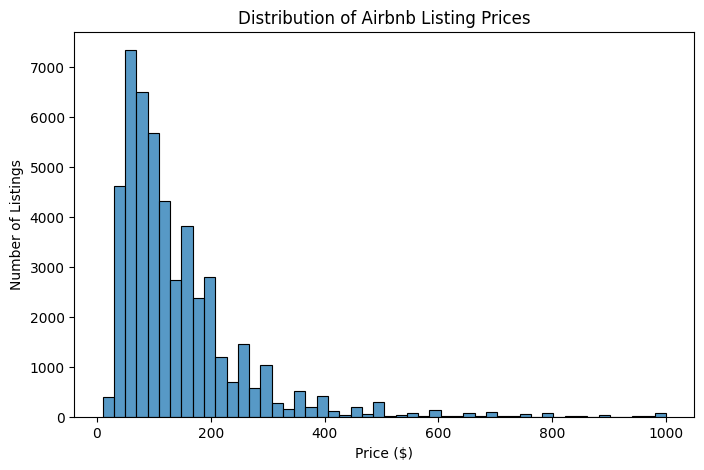

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=50)

plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

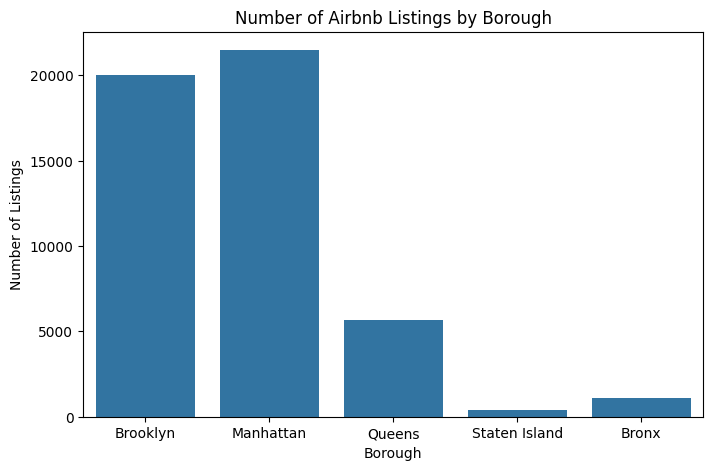

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x='neighbourhood_group', data=df)

plt.title("Number of Airbnb Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")

plt.show()

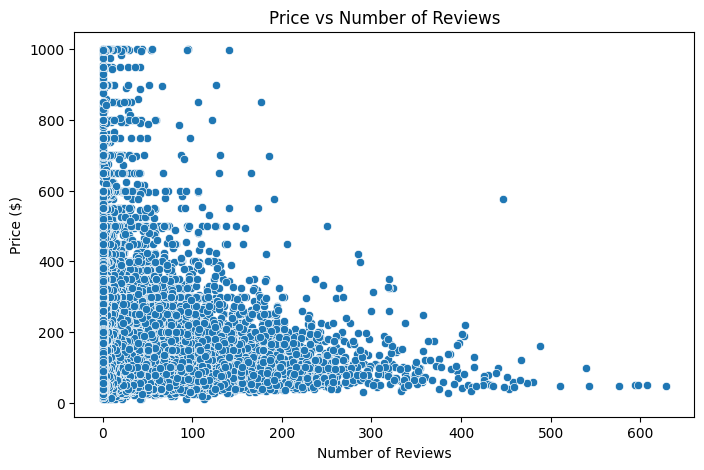

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='number_of_reviews', y='price', data=df)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")

plt.show()

## Summary and Interpretation

This exploratory analysis looked at Airbnb listings in New York City to understand pricing patterns, listing distribution across boroughs, and the relationship between price and reviews.

The price distribution visual shows that most Airbnb listings fall between approx. $50 and $200 per night. The distribution is right-skewed, meaning a small number of listings have very high prices while the majority remain in a moderate price range.

The borough distribution visual indicates that Manhattan and Brooklyn contain the majority of Airbnb listings. Queens has significantly fewer listings, while the Bronx and Staten Island have the smallest number of listings.

The scatter plot comparing price and number of reviews suggests that listings with a large number of reviews often fall within moderate price ranges. Extremely expensive listings tend to have fewer reviews, which may indicate lower booking frequency or more niche accommodations.

One limitation of this analysis is that price alone does not account for other factors such as property size, amenities, or location within each borough. Future analysis could incorporate additional variables to better understand pricing patterns.